<a href="https://colab.research.google.com/github/aodm26/FlightDataUS/blob/main/Group4_visualisations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CN7031 – Big Data Analytics
## TEAM4 Visualisations

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
# Creating SPARK Session
sprk = SparkSession.builder \
    .appName("FlightData") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Reading paquet
DATASET_PATH = "/content/dataset.parquet"
df_clean = df = sprk.read.option("ignoreCorruptFiles", "true").parquet(DATASET_PATH)

The error `Py4JJavaError: An error occurred while calling o39.parquet.: org.apache.spark.SparkException: [FAILED_READ_FILE.CANNOT_READ_FILE_FOOTER] Encountered error while reading file file:/content/dataset.parquet` suggests that the file `/content/dataset.parquet` is either not a valid Parquet file or is corrupted. Let's inspect the file to confirm its type and content.

In [2]:
import os

# Check if the file exists and its size
if os.path.exists(DATASET_PATH):
    print(f"File '{DATASET_PATH}' exists.")
    print(f"File size: {os.path.getsize(DATASET_PATH)} bytes")

    # Attempt to read the first few bytes to guess the file type (for debugging)
    with open(DATASET_PATH, 'rb') as f:
        header = f.read(8) # Read first 8 bytes
        print(f"File header (first 8 bytes): {header}")

    # Use shell command to get file type (if available)
    print("\nRunning 'file' command:")
    !file {DATASET_PATH}

    # Display first few lines (if it's a text-readable format)
    print("\nRunning 'head' command (first 5 lines, if text-readable):")
    !head -n 5 {DATASET_PATH}
else:
    print(f"File '{DATASET_PATH}' does not exist.")

File '/content/dataset.parquet' exists.
File size: 178105758 bytes
File header (first 8 bytes): b'PAR1\x15\x04\x15\x10'

Running 'file' command:
/content/dataset.parquet: Apache Parquet

Running 'head' command (first 5 lines, if text-readable):
PAR1����<  �       �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� �� �����  ,   �� ��

In [3]:
df_clean.printSchema()

root
 |-- year: long (nullable = true)
 |-- month: long (nullable = true)
 |-- day_of_month: long (nullable = true)
 |-- day_of_week: long (nullable = true)
 |-- fl_date: string (nullable = true)
 |-- op_unique_carrier: string (nullable = true)
 |-- op_carrier_fl_num: double (nullable = true)
 |-- origin: string (nullable = true)
 |-- origin_city_name: string (nullable = true)
 |-- origin_state_nm: string (nullable = true)
 |-- dest: string (nullable = true)
 |-- dest_city_name: string (nullable = true)
 |-- dest_state_nm: string (nullable = true)
 |-- crs_dep_time: long (nullable = true)
 |-- dep_time: double (nullable = true)
 |-- dep_delay: double (nullable = true)
 |-- taxi_out: double (nullable = true)
 |-- wheels_off: double (nullable = true)
 |-- wheels_on: double (nullable = true)
 |-- taxi_in: double (nullable = true)
 |-- crs_arr_time: long (nullable = true)
 |-- arr_time: double (nullable = true)
 |-- arr_delay: double (nullable = true)
 |-- is_delayed: integer (nullable = t

In [4]:
print(f"Total rows: {df_clean.count()}")

Total rows: 7079079


In [5]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

In [6]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd

# Consistent style across all charts
sns.set_theme(style="whitegrid", palette="muted")

## --- Delays by Airline ---
## Which airline has the highest % of delayed flights?

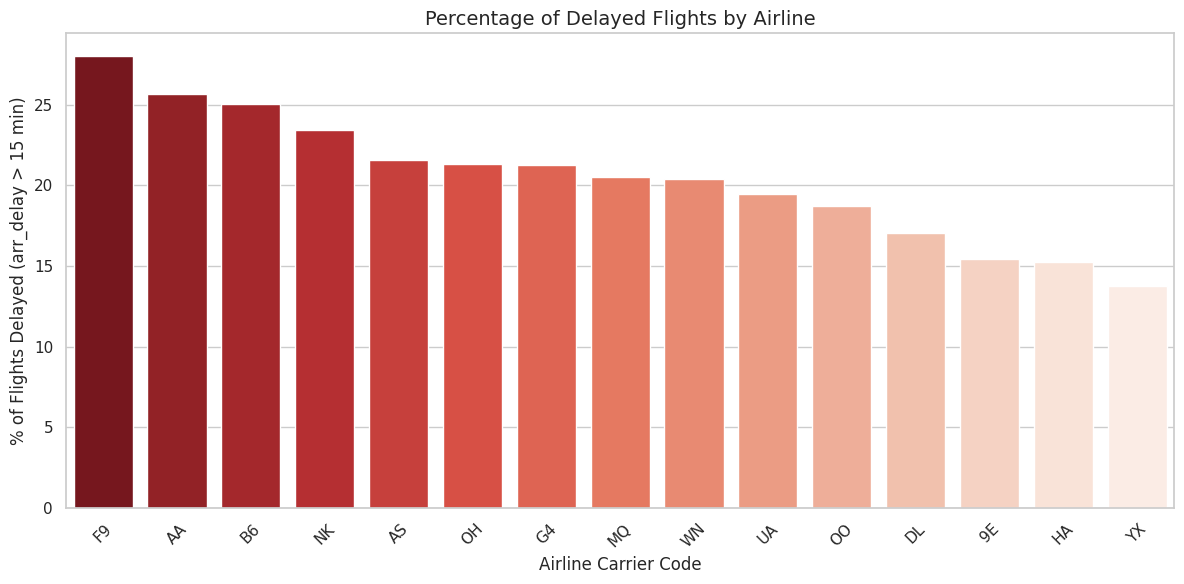

In [7]:
# --- Delays by Airline ---
# Which airline has the highest % of delayed flights?

airline_delay = df_clean.groupBy("op_unique_carrier").agg(
    F.count("*").alias("total_flights"),
    F.sum("is_delayed").alias("delayed_flights"),
    F.avg("arr_delay").alias("avg_arr_delay")
).withColumn(
    "delay_pct",
    (F.col("delayed_flights") / F.col("total_flights") * 100)
).filter(F.col("total_flights") >= 100).orderBy("delay_pct", ascending=False).toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(data=airline_delay, x="op_unique_carrier", y="delay_pct", hue="op_unique_carrier", palette="Reds_r", legend=False)
plt.title("Percentage of Delayed Flights by Airline", fontsize=14)
plt.xlabel("Airline Carrier Code")
plt.ylabel("% of Flights Delayed (arr_delay > 15 min)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("delays_by_airline.png", dpi=150)
plt.show()

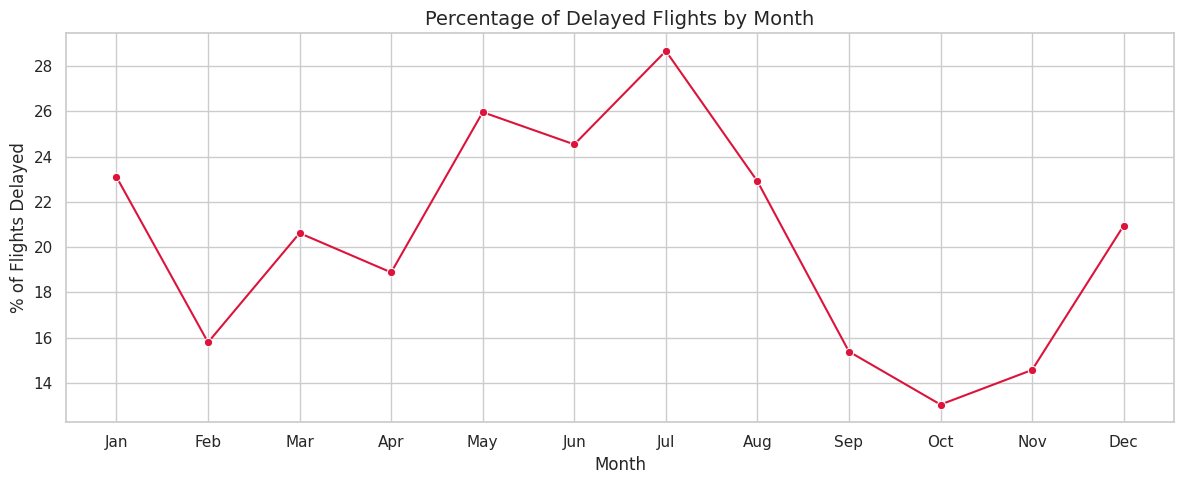

In [8]:
# --- Delays by Month ---
# Which months have the most delays? (seasonal patterns)

month_delay = df_clean.groupBy("month").agg(
    F.count("*").alias("total_flights"),
    F.sum("is_delayed").alias("delayed_flights"),
    F.avg("arr_delay").alias("avg_arr_delay")
).withColumn(
    "delay_pct",
    (F.col("delayed_flights") / F.col("total_flights") * 100)
).orderBy("month").toPandas()

month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
month_delay["month_name"] = month_delay["month"].map(month_names)

plt.figure(figsize=(12, 5))
sns.lineplot(data=month_delay, x="month_name", y="delay_pct", marker="o", color="crimson")
plt.title("Percentage of Delayed Flights by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("% of Flights Delayed")
plt.tight_layout()
plt.savefig("delays_by_month.png", dpi=150)
plt.show()


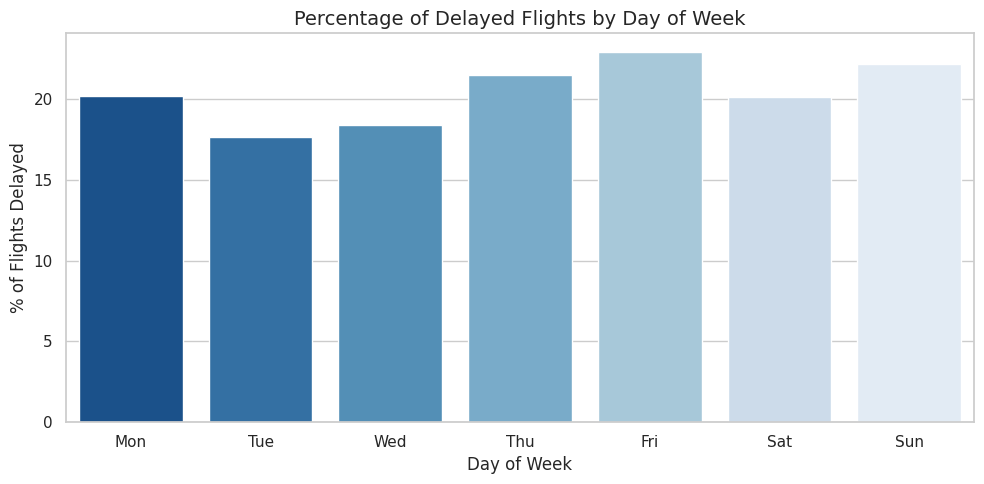

In [9]:
# --- Delays by Day of Week ---
# Are certain days worse for delays?

dow_delay = df_clean.groupBy("day_of_week").agg(
    F.count("*").alias("total_flights"),
    F.sum("is_delayed").alias("delayed_flights")
).withColumn(
    "delay_pct",
    (F.col("delayed_flights") / F.col("total_flights") * 100)
).orderBy("day_of_week").toPandas()

dow_names = {1:"Mon", 2:"Tue", 3:"Wed", 4:"Thu", 5:"Fri", 6:"Sat", 7:"Sun"}
dow_delay["day_name"] = dow_delay["day_of_week"].map(dow_names)

plt.figure(figsize=(10, 5))
sns.barplot(data=dow_delay, x="day_name", y="delay_pct", hue="day_name", palette="Blues_r", legend=False)
plt.title("Percentage of Delayed Flights by Day of Week", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("% of Flights Delayed")
plt.tight_layout()
plt.savefig("delays_by_day_of_week.png", dpi=150)
plt.show()

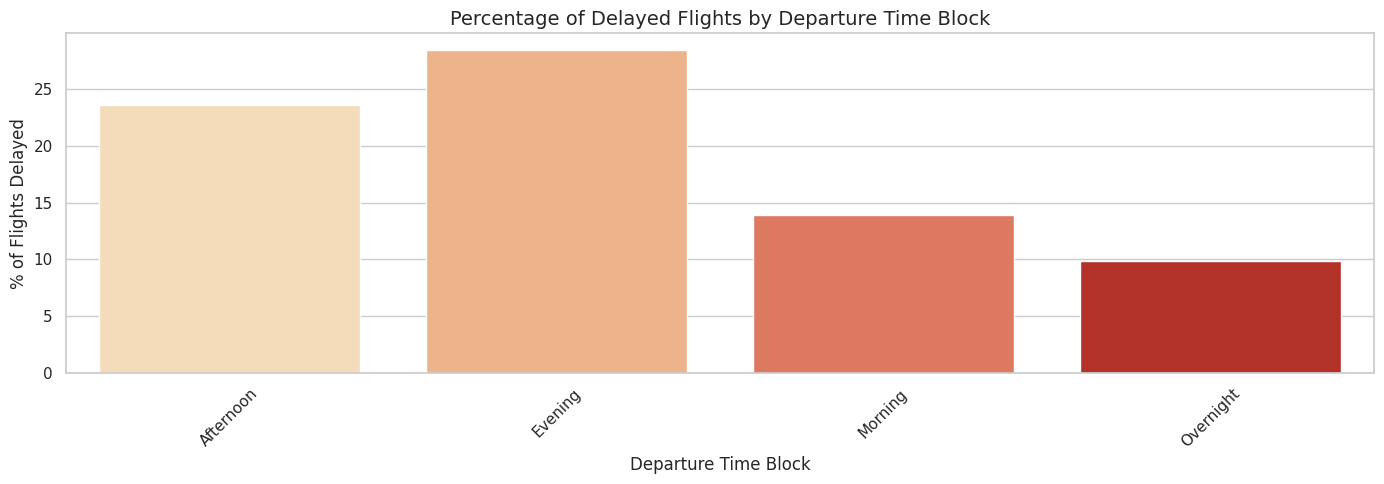

In [10]:
# --- Delays by Time Block ---
# Which departure time block has the most delays?

time_delay = df_clean.groupBy("dep_time_block").agg(
    F.count("*").alias("total_flights"),
    F.sum("is_delayed").alias("delayed_flights")
).withColumn(
    "delay_pct",
    (F.col("delayed_flights") / F.col("total_flights") * 100)
).filter(F.col("total_flights") >= 100).orderBy("dep_time_block").toPandas()

plt.figure(figsize=(14, 5))
sns.barplot(data=time_delay, x="dep_time_block", y="delay_pct", hue="dep_time_block", palette="OrRd", legend=False)
plt.title("Percentage of Delayed Flights by Departure Time Block", fontsize=14)
plt.xlabel("Departure Time Block")
plt.ylabel("% of Flights Delayed")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("delays_by_time_block.png", dpi=150)
plt.show()

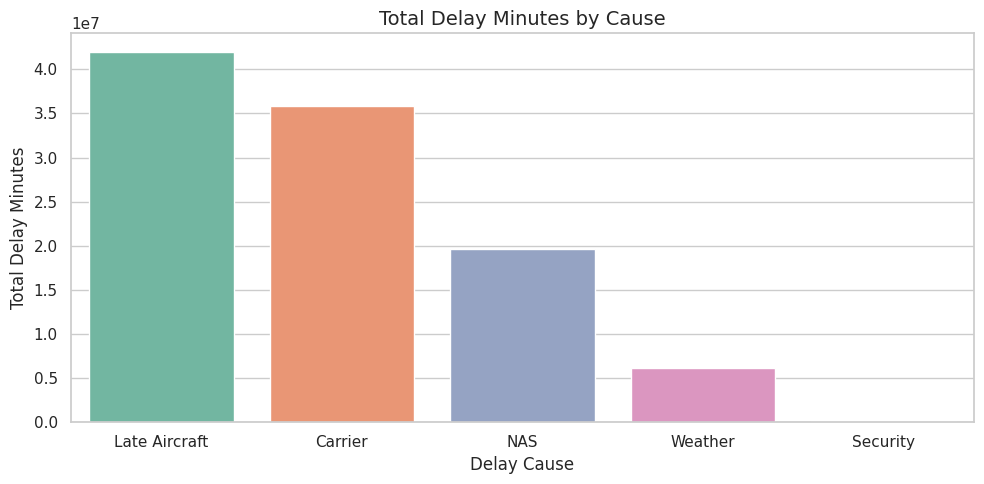

In [11]:
# --- Delay Causes Breakdown ---
# What causes delays the most overall?

causes = df_clean.agg(
    F.sum("carrier_delay").alias("Carrier"),
    F.sum("weather_delay").alias("Weather"),
    F.sum("nas_delay").alias("NAS"),
    F.sum("security_delay").alias("Security"),
    F.sum("late_aircraft_delay").alias("Late Aircraft")
).toPandas().T.reset_index()
causes.columns = ["cause", "total_minutes"]
causes = causes.sort_values("total_minutes", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=causes, x="cause", y="total_minutes", hue="cause", palette="Set2", legend=False)
plt.title("Total Delay Minutes by Cause", fontsize=14)
plt.xlabel("Delay Cause")
plt.ylabel("Total Delay Minutes")
plt.tight_layout()
plt.savefig("delay_causes.png", dpi=150)
plt.show()

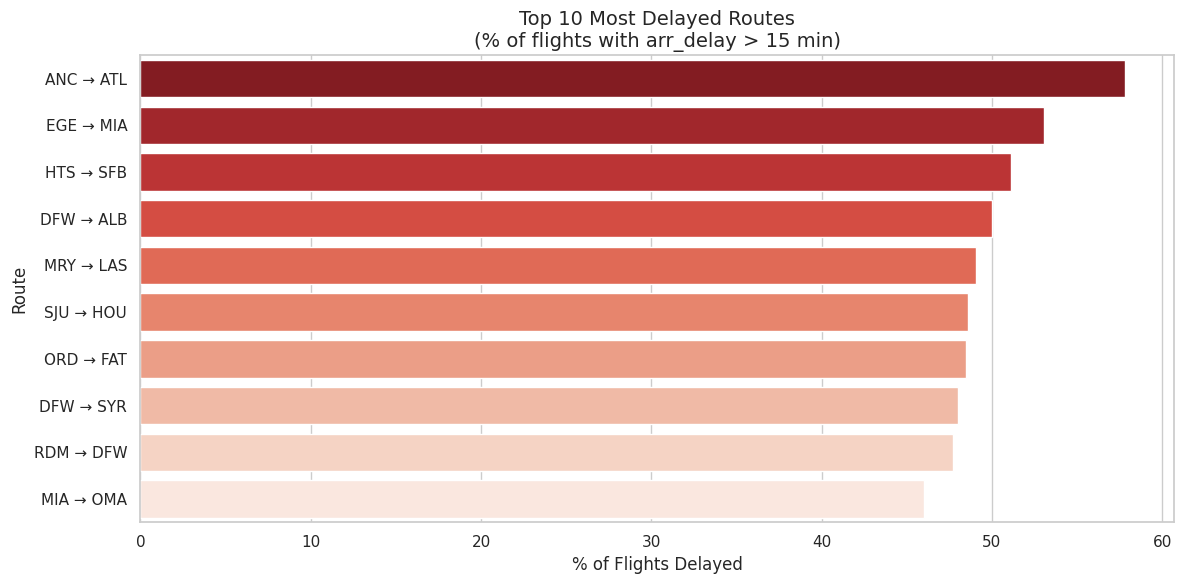

In [12]:
# --- Top 10 Most Delayed Routes ---
# Which routes have the highest % of delayed flights?

route_delay = df_clean.groupBy("origin", "dest").agg(
    F.count("*").alias("total_flights"),
    F.sum("is_delayed").alias("delayed_flights")
).withColumn(
    "delay_pct",
    (F.col("delayed_flights") / F.col("total_flights") * 100)
).filter(F.col("total_flights") >= 100).orderBy("delay_pct", ascending=False).limit(10).toPandas()

route_delay["route"] = route_delay["origin"] + " → " + route_delay["dest"]

plt.figure(figsize=(12, 6))
sns.barplot(data=route_delay, x="delay_pct", y="route", hue="route", palette="Reds_r", legend=False)
plt.title("Top 10 Most Delayed Routes\n(% of flights with arr_delay > 15 min)", fontsize=14)
plt.xlabel("% of Flights Delayed")
plt.ylabel("Route")
plt.tight_layout()
plt.savefig("top10_delayed_routes.png", dpi=150)
plt.show()

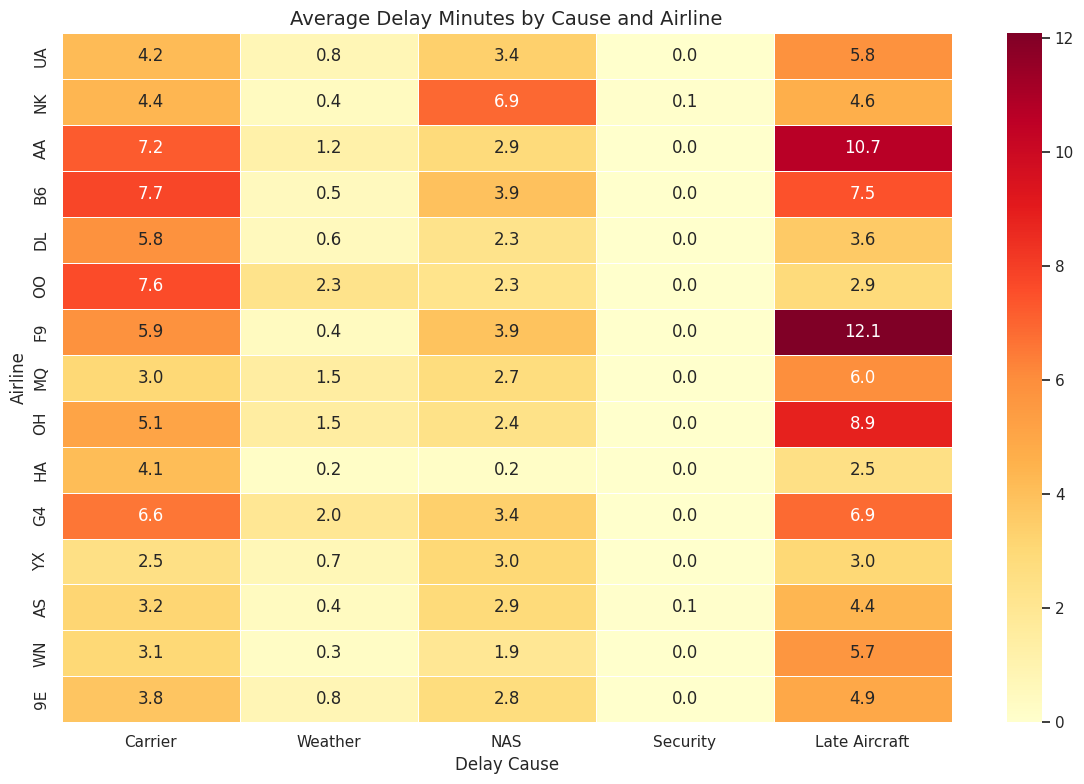

In [13]:
# --- Delay causes heatmap by Airline ---
# Which airline suffers most from which delay cause?

heatmap_data = df_clean.groupBy("op_unique_carrier").agg(
    F.avg("carrier_delay").alias("Carrier"),
    F.avg("weather_delay").alias("Weather"),
    F.avg("nas_delay").alias("NAS"),
    F.avg("security_delay").alias("Security"),
    F.avg("late_aircraft_delay").alias("Late Aircraft")
).toPandas().set_index("op_unique_carrier")

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.title("Average Delay Minutes by Cause and Airline", fontsize=14)
plt.xlabel("Delay Cause")
plt.ylabel("Airline")
plt.tight_layout()
plt.savefig("heatmap_delay_cause_airline.png", dpi=150)
plt.show()

## Event 1

### July 19th CrowdStrike IT Outage
July 19-25, 2024 Delta Air Lines experienced a massive operational disruption following the CrowdStrike IT outage

month=7
op_unique_carrier='DL'
spike in carrier_delay during those dates July 19-25



In [14]:
# =============================================================
# CrowdStrike IT Outage Event Analysis
# Delta Airlines (DL) - July 2024
# Outage period: July 19-25, 2024
# =============================================================

from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid")

In [15]:
# --- Filter Delta flights in July 2024 ---
delta_july = df_clean.filter(
    (F.col("op_unique_carrier") == "DL") & # DELTA
    (F.col("month") == 7) # july
).groupBy("day_of_month").agg(
    F.count("*").alias("total_flights"),
    F.sum("is_delayed").alias("delayed_flights"),
    F.avg("arr_delay").alias("avg_arr_delay"),
    F.avg("carrier_delay").alias("avg_carrier_delay"), # avg_carrier_delay - average number of minutes that flights were delayed due to carrier-related issues
    F.sum("cancelled").alias("total_cancelled")
).withColumn(
    "delay_pct",
    (F.col("delayed_flights") / F.col("total_flights") * 100)
).orderBy("day_of_month").toPandas()

print(delta_july[["day_of_month", "total_flights", "delayed_flights", "delay_pct", "avg_carrier_delay", "total_cancelled"]])

    day_of_month  total_flights  delayed_flights  delay_pct  \
0              1           2734              432  15.801024   
1              2           2715              243   8.950276   
2              3           2907              349  12.005504   
3              4           2446              185   7.563369   
4              5           2486              568  22.847949   
5              6           2700              552  20.444444   
6              7           3092              794  25.679172   
7              8           3161              811  25.656438   
8              9           2980              804  26.979866   
9             10           3008              698  23.204787   
10            11           3162              573  18.121442   
11            12           3166              945  29.848389   
12            13           2722              607  22.299780   
13            14           3158              927  29.354022   
14            15           3162              894  28.27

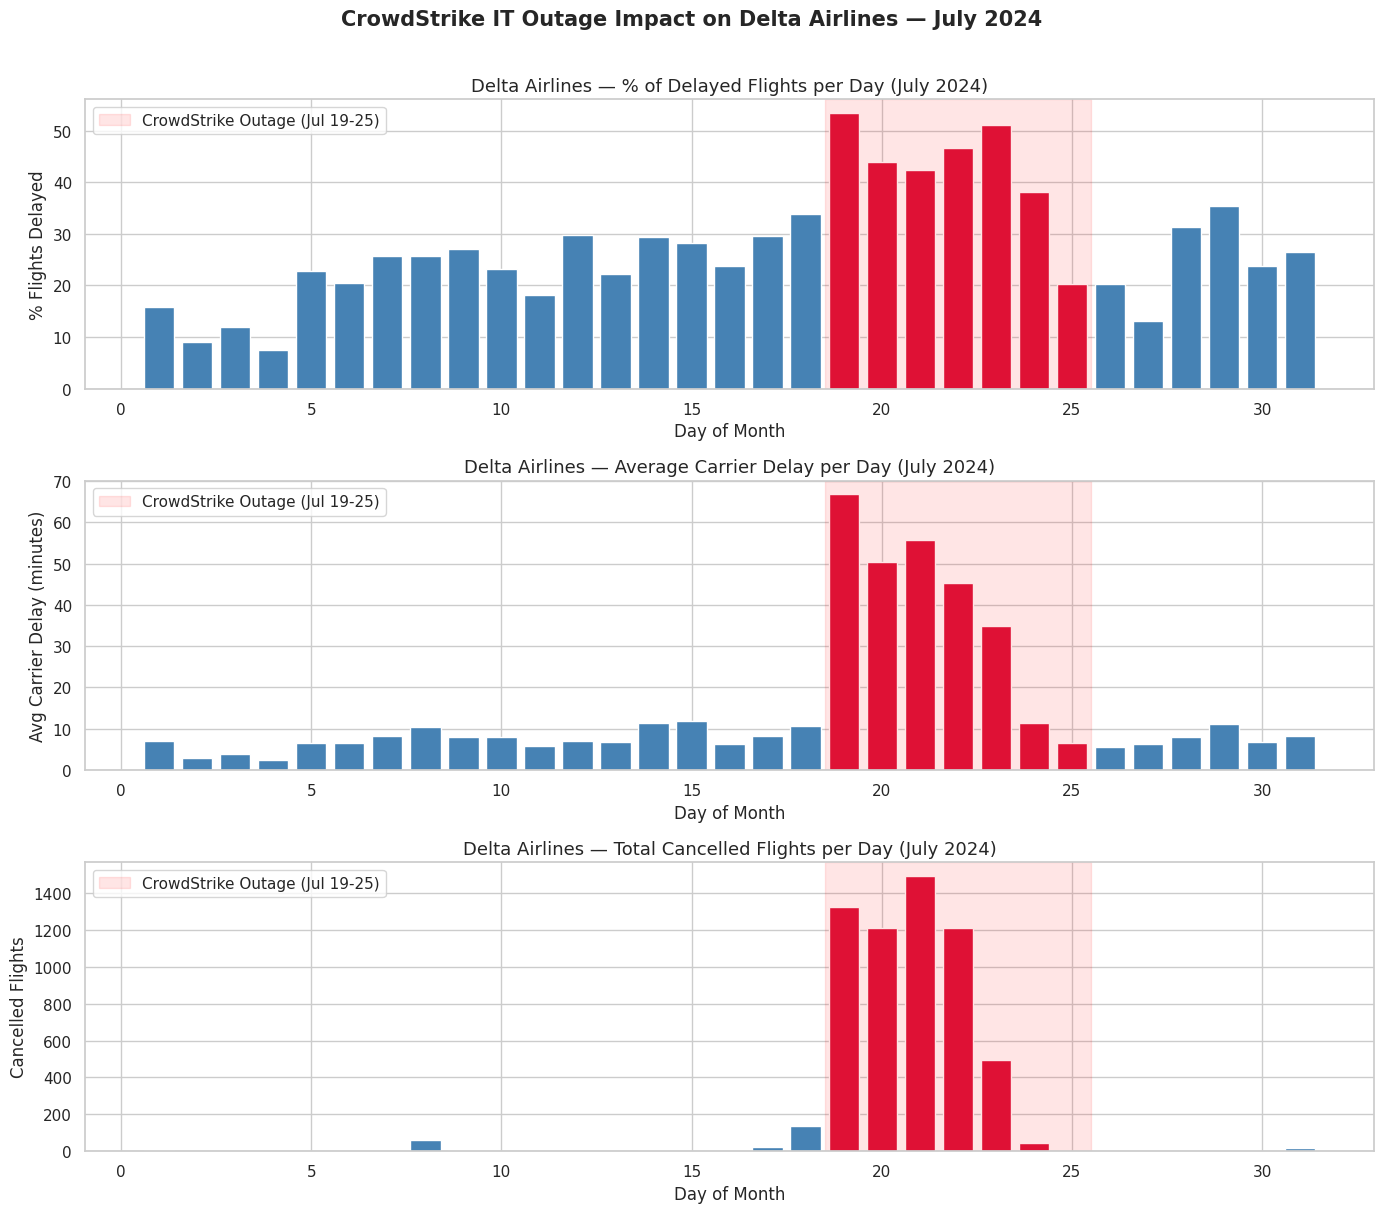

In [16]:
# --- Visualise Delta delay % across July ---
# Highlight the CrowdStrike outage period (July 19-25)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Chart 1: % of delayed flights per day
axes[0].bar(delta_july["day_of_month"], delta_july["delay_pct"],
            color=["crimson" if 19 <= d <= 25 else "steelblue"
                   for d in delta_july["day_of_month"]])
axes[0].axvspan(18.5, 25.5, alpha=0.1, color="red", label="CrowdStrike Outage (Jul 19-25)")
axes[0].set_title("Delta Airlines — % of Delayed Flights per Day (July 2024)", fontsize=13)
axes[0].set_xlabel("Day of Month")
axes[0].set_ylabel("% Flights Delayed")
axes[0].legend()

# Chart 2: Average carrier delay per day
axes[1].bar(delta_july["day_of_month"], delta_july["avg_carrier_delay"],
            color=["crimson" if 19 <= d <= 25 else "steelblue"
                   for d in delta_july["day_of_month"]])
axes[1].axvspan(18.5, 25.5, alpha=0.1, color="red", label="CrowdStrike Outage (Jul 19-25)")
axes[1].set_title("Delta Airlines — Average Carrier Delay per Day (July 2024)", fontsize=13)
axes[1].set_xlabel("Day of Month")
axes[1].set_ylabel("Avg Carrier Delay (minutes)")
axes[1].legend()

# Chart 3: Total cancelled flights per day
axes[2].bar(delta_july["day_of_month"], delta_july["total_cancelled"],
            color=["crimson" if 19 <= d <= 25 else "steelblue"
                   for d in delta_july["day_of_month"]])
axes[2].axvspan(18.5, 25.5, alpha=0.1, color="red", label="CrowdStrike Outage (Jul 19-25)")
axes[2].set_title("Delta Airlines — Total Cancelled Flights per Day (July 2024)", fontsize=13)
axes[2].set_xlabel("Day of Month")
axes[2].set_ylabel("Cancelled Flights")
axes[2].legend()

plt.suptitle("CrowdStrike IT Outage Impact on Delta Airlines — July 2024",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("crowdstrike_delta_july2024.png", dpi=150, bbox_inches="tight")
plt.show()

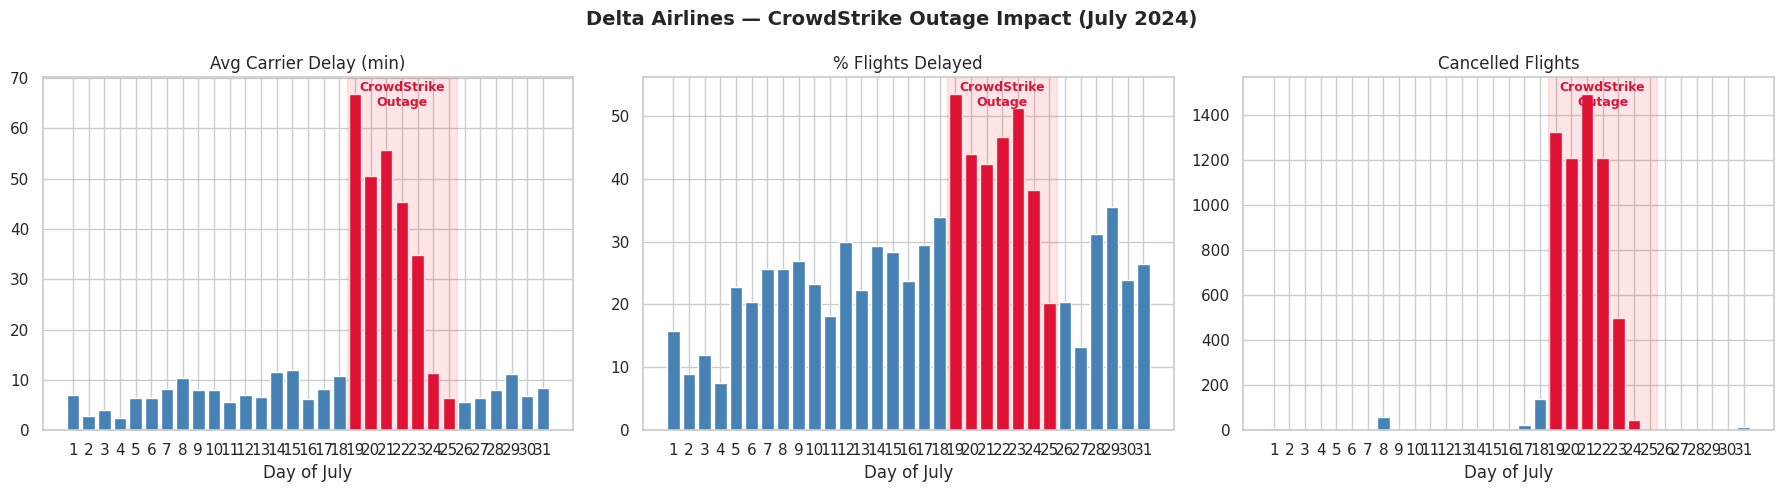

In [19]:
# Visualise Delta delay % across July - all in one

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ["crimson" if 19 <= d <= 25 else "steelblue"
          for d in delta_july["day_of_month"]]

days = delta_july["day_of_month"]

# Chart 1: Carrier delay
axes[0].bar(days, delta_july["avg_carrier_delay"], color=colors)
axes[0].axvspan(18.5, 25.5, alpha=0.1, color="red")
axes[0].set_title("Avg Carrier Delay (min)", fontsize=12)
axes[0].set_xlabel("Day of July")
axes[0].set_xticks(days)

# Chart 2: % delayed
axes[1].bar(days, delta_july["delay_pct"], color=colors)
axes[1].axvspan(18.5, 25.5, alpha=0.1, color="red")
axes[1].set_title("% Flights Delayed", fontsize=12)
axes[1].set_xlabel("Day of July")
axes[1].set_xticks(days)

# Chart 3: Cancellations
axes[2].bar(days, delta_july["total_cancelled"], color=colors)
axes[2].axvspan(18.5, 25.5, alpha=0.1, color="red")
axes[2].set_title("Cancelled Flights", fontsize=12)
axes[2].set_xlabel("Day of July")
axes[2].set_xticks(days)

# Add outage label to each chart
for ax in axes:
    ax.text(22, ax.get_ylim()[1] * 0.92, "CrowdStrike\nOutage",
            ha="center", fontsize=9, color="crimson", fontweight="bold")

plt.suptitle("Delta Airlines — CrowdStrike Outage Impact (July 2024)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("crowdstrike_delta_july2024.png", dpi=150)
plt.show()

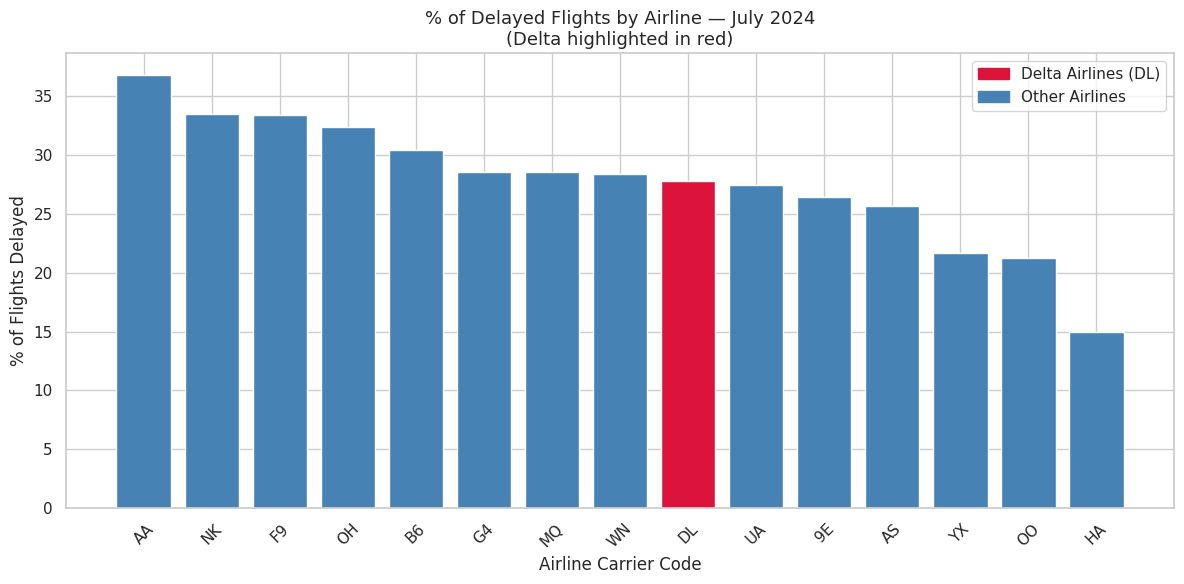

In [20]:
# --- Compare Delta vs other airlines in July ---
# Was the spike unique to Delta or did all airlines suffer?

all_airlines_july = df_clean.filter(F.col("month") == 7).groupBy("op_unique_carrier").agg(
    F.count("*").alias("total_flights"),
    F.sum("is_delayed").alias("delayed_flights"),
    F.avg("carrier_delay").alias("avg_carrier_delay")
).withColumn(
    "delay_pct",
    (F.col("delayed_flights") / F.col("total_flights") * 100)
).filter(F.col("total_flights") >= 100).orderBy("delay_pct", ascending=False).toPandas()

# Highlight Delta
colors = ["crimson" if c == "DL" else "steelblue" for c in all_airlines_july["op_unique_carrier"]]

plt.figure(figsize=(12, 6))
plt.bar(all_airlines_july["op_unique_carrier"], all_airlines_july["delay_pct"], color=colors)
plt.title("% of Delayed Flights by Airline — July 2024\n(Delta highlighted in red)", fontsize=13)
plt.xlabel("Airline Carrier Code")
plt.ylabel("% of Flights Delayed")
dl_patch = mpatches.Patch(color="crimson", label="Delta Airlines (DL)")
other_patch = mpatches.Patch(color="steelblue", label="Other Airlines")
plt.legend(handles=[dl_patch, other_patch])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("crowdstrike_delta_vs_others_july2024.png", dpi=150)
plt.show()


Delta Airlines — Before / During / After CrowdStrike Outage:
                    period  avg_carrier_delay  avg_delay_pct  total_cancelled
 After Outage\n(Jul 26-31)           7.665412      25.105535               17
 Before Outage\n(Jul 1-18)           7.313964      22.453709              253
During Outage\n(Jul 19-25)          38.693146      42.261161             5783


/tmp/ipykernel_7411/2957067190.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=period_summary, x="period", y="avg_carrier_delay",
/tmp/ipykernel_7411/2957067190.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=period_summary, x="period", y="avg_delay_pct",


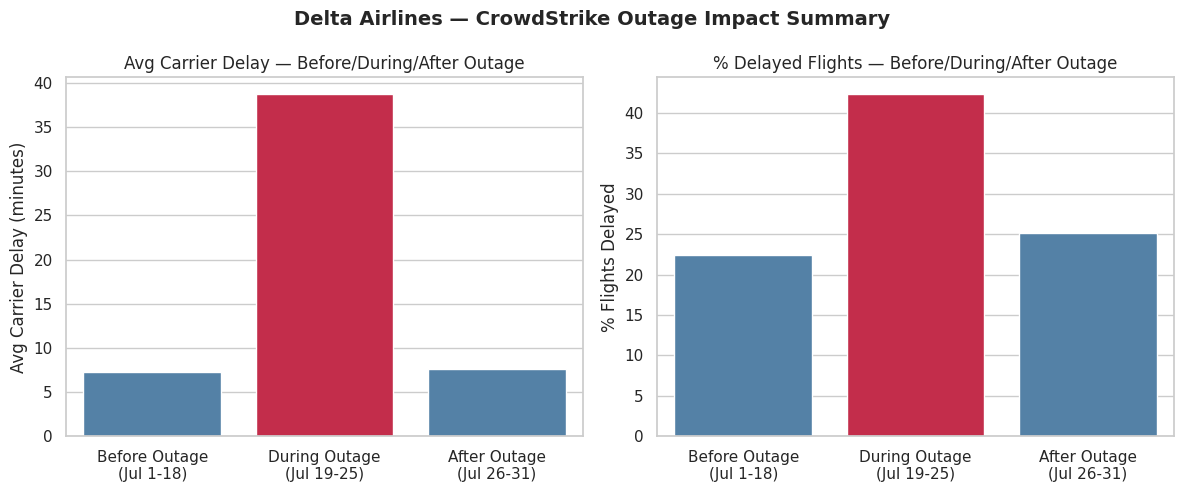

In [21]:
# --- Before vs During vs After outage for Delta ---
# Compare avg carrier delay in 3 periods

delta_july["period"] = delta_july["day_of_month"].apply(
    lambda d: "During Outage\n(Jul 19-25)" if 19 <= d <= 25
    else ("Before Outage\n(Jul 1-18)" if d < 19 else "After Outage\n(Jul 26-31)")
)

period_summary = delta_july.groupby("period").agg(
    avg_carrier_delay=("avg_carrier_delay", "mean"),
    avg_delay_pct=("delay_pct", "mean"),
    total_cancelled=("total_cancelled", "sum")
).reset_index()

print("\nDelta Airlines — Before / During / After CrowdStrike Outage:")
print(period_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = ["Before Outage\n(Jul 1-18)", "During Outage\n(Jul 19-25)", "After Outage\n(Jul 26-31)"]
colors = ["steelblue", "crimson", "steelblue"]

sns.barplot(data=period_summary, x="period", y="avg_carrier_delay",
            order=order, palette=colors, ax=axes[0])
axes[0].set_title("Avg Carrier Delay — Before/During/After Outage", fontsize=12)
axes[0].set_ylabel("Avg Carrier Delay (minutes)")
axes[0].set_xlabel("")

sns.barplot(data=period_summary, x="period", y="avg_delay_pct",
            order=order, palette=colors, ax=axes[1])
axes[1].set_title("% Delayed Flights — Before/During/After Outage", fontsize=12)
axes[1].set_ylabel("% Flights Delayed")
axes[1].set_xlabel("")

plt.suptitle("Delta Airlines — CrowdStrike Outage Impact Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("crowdstrike_before_during_after.png", dpi=150)
plt.show()

### Event 2: Winter/Severe Weather Storms — various months 2024

Analysis of aviation data found that nearly one in four US flights was delayed or cancelled, with states like West Virginia, New Jersey, Virginia, Kansas and Florida showing the highest combined disruption rates. Here we visualise weather_delay spikes by month to identify storm periods.


In [22]:
# =============================================================
# CN7031 - Weather/Storm Disruptions Analysis 2024
# Visualise weather_delay spikes by month and affected states
# =============================================================

from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid")

# States with highest disruption rates (from research)
HIGH_DISRUPTION_STATES = ["West Virginia", "New Jersey", "Virginia", "Kansas", "Florida"]

In [23]:
# --- Weather delay by month (all airlines) ---
weather_monthly = df_clean.groupBy("month").agg(
    F.count("*").alias("total_flights"),
    F.sum("is_delayed").alias("delayed_flights"),
    F.avg("weather_delay").alias("avg_weather_delay"),
    F.sum("weather_delay").alias("total_weather_delay"),
    F.sum("cancelled").alias("total_cancelled")
).withColumn(
    "delay_pct",
    (F.col("delayed_flights") / F.col("total_flights") * 100)
).orderBy("month").toPandas()

month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
weather_monthly["month_name"] = weather_monthly["month"].map(month_names)

print(weather_monthly[["month_name", "total_flights", "avg_weather_delay", "total_weather_delay", "total_cancelled"]])

   month_name  total_flights  avg_weather_delay  total_weather_delay  \
0         Jan         547271           1.789534               979360   
1         Feb         519220           0.539937               280346   
2         Mar         591766           0.604903               357961   
3         Apr         582205           0.666837               388236   
4         May         609743           1.393556               849711   
5         Jun         611132           1.089707               665955   
6         Jul         634613           1.055513               669842   
7         Aug         619025           1.014408               627944   
8         Sep         582622           0.453141               264010   
9         Oct         615497           0.268927               165524   
10        Nov         575404           0.499734               287549   
11        Dec         590581           1.116587               659435   

    total_cancelled  
0             20389  
1              3001

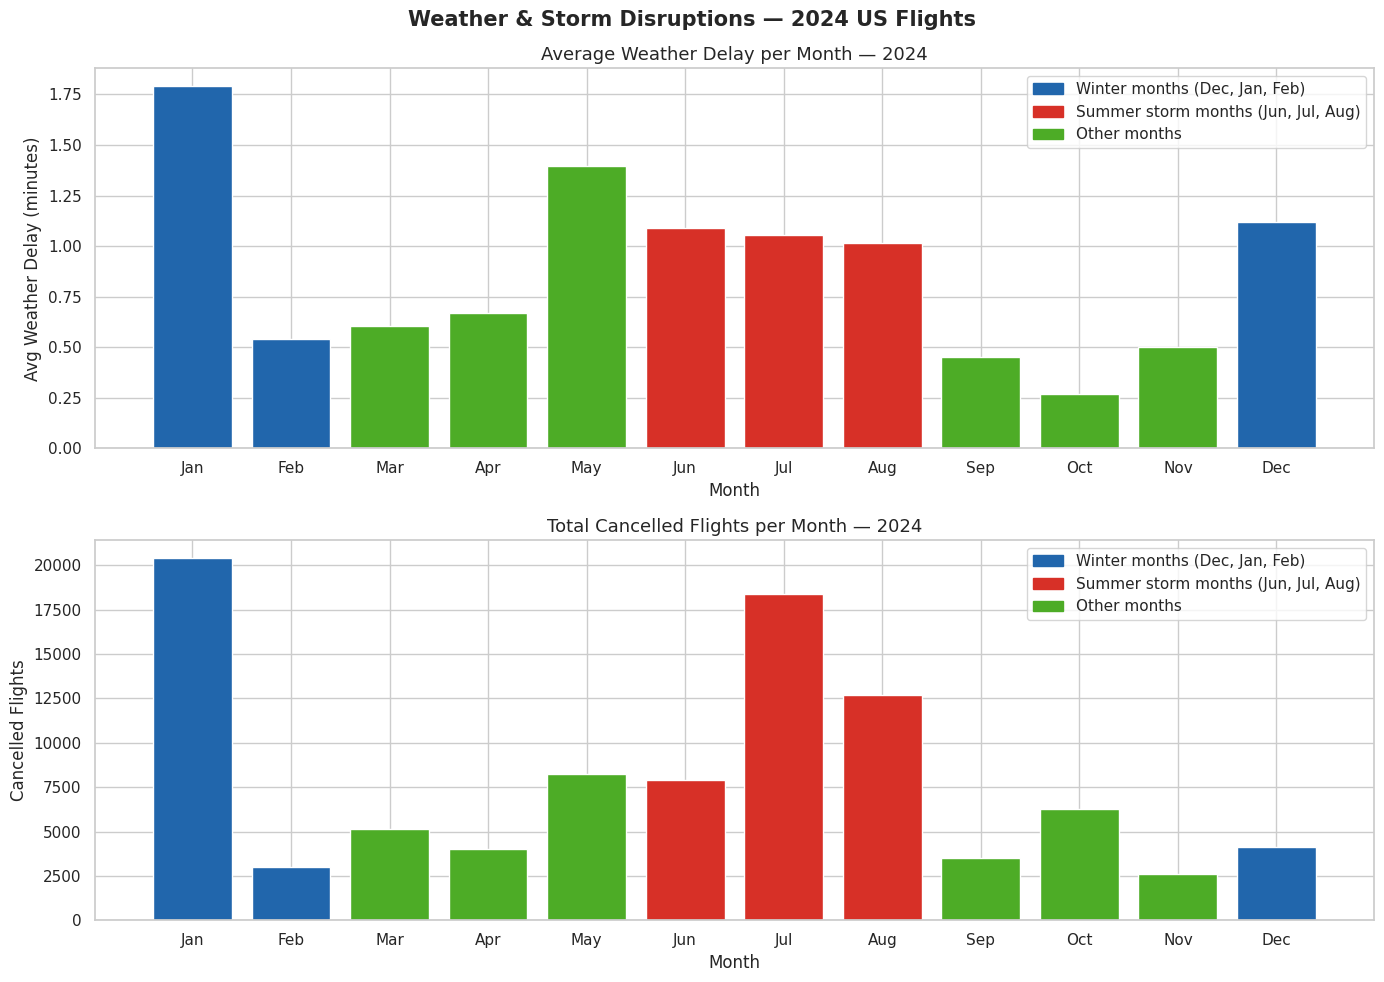

In [24]:
# --- Weather delay spikes by month ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Chart 1: Average weather delay per month
axes[0].bar(weather_monthly["month_name"], weather_monthly["avg_weather_delay"],
            color=["#2166ac" if m in [12, 1, 2] else  # Winter months
                   "#d73027" if m in [6, 7, 8] else   # Summer storm months
                   "#4dac26"                            # Other months
                   for m in weather_monthly["month"]])
axes[0].set_title("Average Weather Delay per Month — 2024", fontsize=13)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Weather Delay (minutes)")
winter = mpatches.Patch(color="#2166ac", label="Winter months (Dec, Jan, Feb)")
summer = mpatches.Patch(color="#d73027", label="Summer storm months (Jun, Jul, Aug)")
other  = mpatches.Patch(color="#4dac26", label="Other months")
axes[0].legend(handles=[winter, summer, other])

# Chart 2: Total cancelled flights per month
axes[1].bar(weather_monthly["month_name"], weather_monthly["total_cancelled"],
            color=["#2166ac" if m in [12, 1, 2] else
                   "#d73027" if m in [6, 7, 8] else
                   "#4dac26"
                   for m in weather_monthly["month"]])
axes[1].set_title("Total Cancelled Flights per Month — 2024", fontsize=13)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Cancelled Flights")
axes[1].legend(handles=[winter, summer, other])

plt.suptitle("Weather & Storm Disruptions — 2024 US Flights",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("weather_delays_by_month.png", dpi=150)
plt.show()

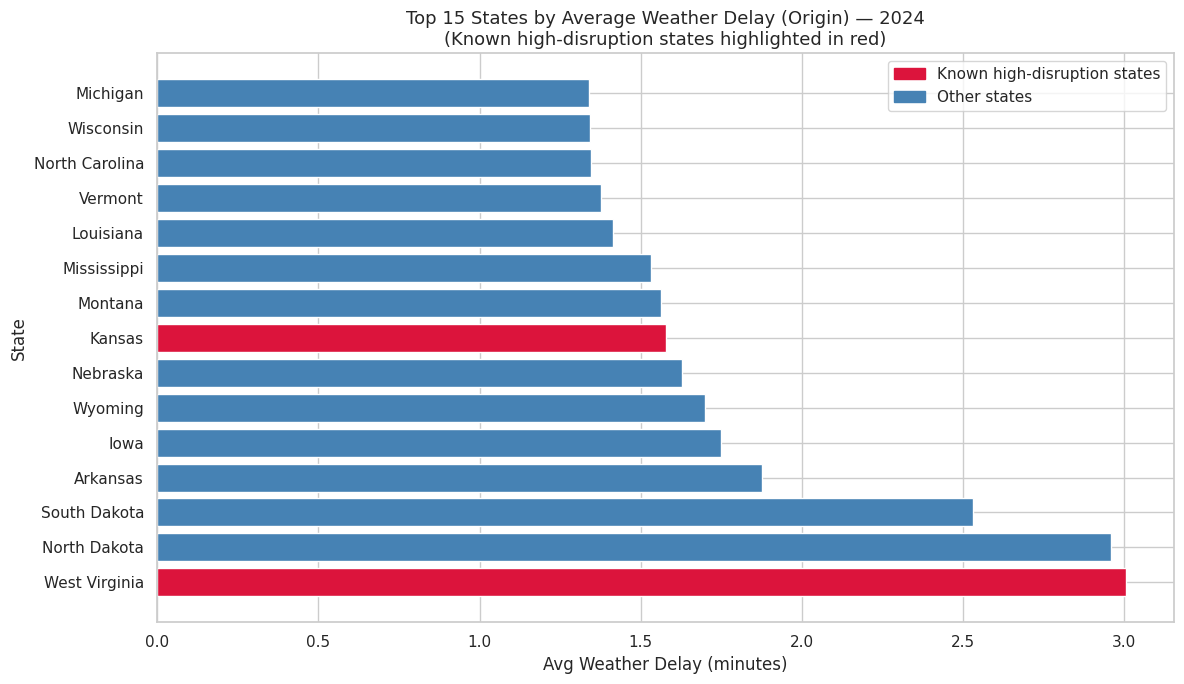

In [25]:
# --- Most weather-affected states (origin) ---
state_weather = df_clean.groupBy("origin_state_nm").agg(
    F.count("*").alias("total_flights"),
    F.avg("weather_delay").alias("avg_weather_delay"),
    F.sum("weather_delay").alias("total_weather_delay"),
    F.sum("cancelled").alias("total_cancelled")
).withColumn(
    "disruption_rate",
    (F.col("total_cancelled") / F.col("total_flights") * 100)
).filter(F.col("total_flights") >= 500).orderBy("avg_weather_delay", ascending=False).limit(15).toPandas()

# Highlight the known high-disruption states
state_weather["color"] = state_weather["origin_state_nm"].apply(
    lambda s: "crimson" if s in HIGH_DISRUPTION_STATES else "steelblue"
)

plt.figure(figsize=(12, 7))
plt.barh(state_weather["origin_state_nm"], state_weather["avg_weather_delay"],
         color=state_weather["color"])
plt.title("Top 15 States by Average Weather Delay (Origin) — 2024\n(Known high-disruption states highlighted in red)", fontsize=13)
plt.xlabel("Avg Weather Delay (minutes)")
plt.ylabel("State")
high = mpatches.Patch(color="crimson", label="Known high-disruption states")
other = mpatches.Patch(color="steelblue", label="Other states")
plt.legend(handles=[high, other])
plt.tight_layout()
plt.savefig("weather_delays_by_state.png", dpi=150)
plt.show()

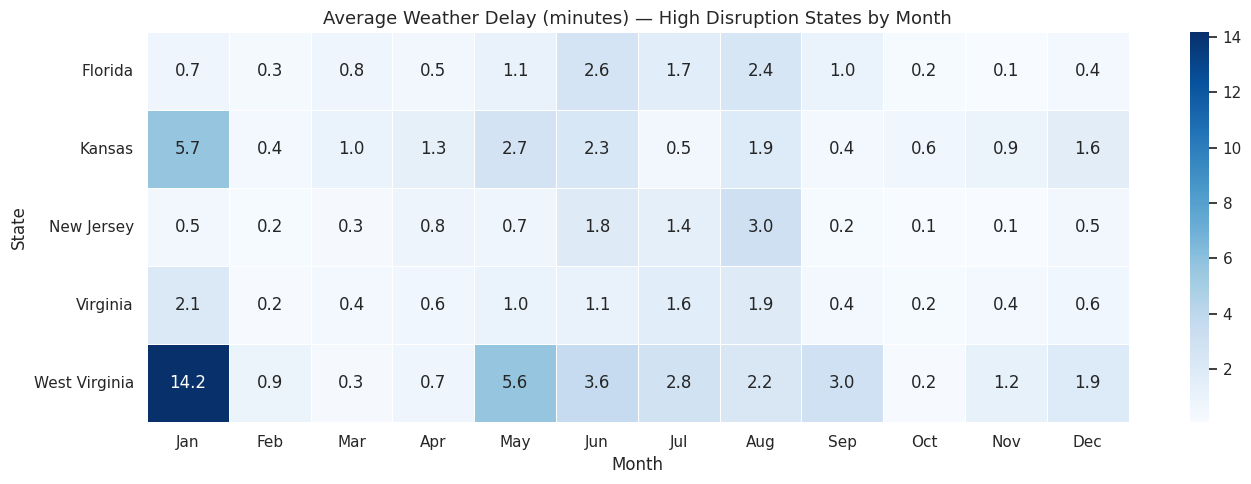

In [26]:
# --- Weather delay heatmap — state vs month ---
# Which state had the worst weather in which month?

heatmap_data = df_clean.filter(
    F.col("origin_state_nm").isin(HIGH_DISRUPTION_STATES)
).groupBy("origin_state_nm", "month").agg(
    F.avg("weather_delay").alias("avg_weather_delay")
).orderBy("origin_state_nm", "month").toPandas()

heatmap_pivot = heatmap_data.pivot(index="origin_state_nm", columns="month", values="avg_weather_delay")
heatmap_pivot.columns = [month_names[m] for m in heatmap_pivot.columns]

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_pivot, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Average Weather Delay (minutes) — High Disruption States by Month", fontsize=13)
plt.xlabel("Month")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("weather_heatmap_state_month.png", dpi=150)
plt.show()

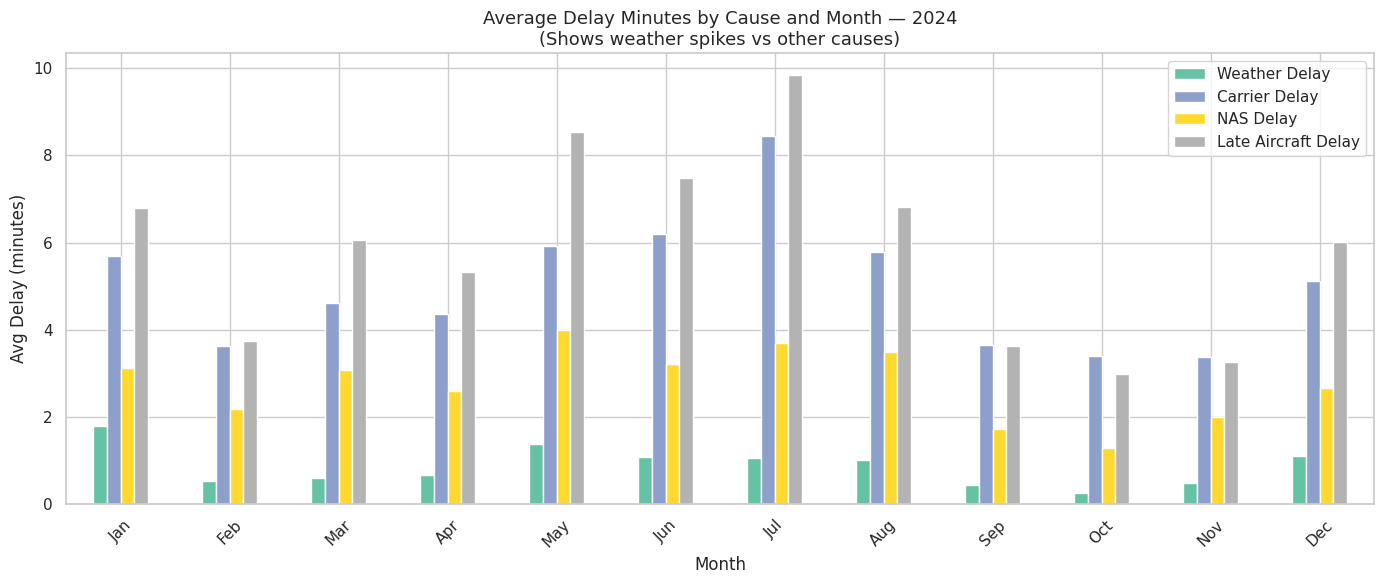

In [27]:
# --- Weather vs Carrier delay comparison by month ---
# Show that winter spikes are weather-driven, not carrier-driven

delay_comparison = df_clean.groupBy("month").agg(
    F.avg("weather_delay").alias("Weather Delay"),
    F.avg("carrier_delay").alias("Carrier Delay"),
    F.avg("nas_delay").alias("NAS Delay"),
    F.avg("late_aircraft_delay").alias("Late Aircraft Delay")
).orderBy("month").toPandas()

delay_comparison["month_name"] = delay_comparison["month"].map(month_names)
delay_comparison = delay_comparison.set_index("month_name")
delay_comparison = delay_comparison.drop(columns=["month"])

delay_comparison.plot(kind="bar", figsize=(14, 6), colormap="Set2")
plt.title("Average Delay Minutes by Cause and Month — 2024\n(Shows weather spikes vs other causes)", fontsize=13)
plt.xlabel("Month")
plt.ylabel("Avg Delay (minutes)")
plt.xticks(rotation=45)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("delay_causes_by_month.png", dpi=150)
plt.show()

### Flow Maps

In [28]:
import sys
!{sys.executable} -m pip install folium

Top 20 most delayed routes:
   origin dest  total_flights  avg_arr_delay  delay_pct
0     RDM  DFW            132      87.429688  47.727273
1     EGE  MIA            132      75.304688  53.030303
2     RNO  JFK            122      73.786325  36.065574
3     DFW  RDM            132      62.961240  41.666667
4     IDA  LAS            109      59.605505  36.697248
5     SNA  MIA            194      57.306878  26.288660
6     JAC  DFW            622      56.271382  30.707395
7     EGE  JFK            105      56.225490  40.000000
8     ANC  ATL            109      56.114286  57.798165
9     MSO  LAS            117      55.465517  31.623932
10    HYA  JFK            104      55.020833  38.461538
11    EYW  DFW            541      53.851351  43.807763
12    RAP  CLT            123      51.157025  45.528455
13    MRY  LAS            106      51.114286  49.056604
14    HTS  PIE            167      51.100000  41.317365
15    HDN  DFW            185      49.456044  34.054054
16    STS  DFW      

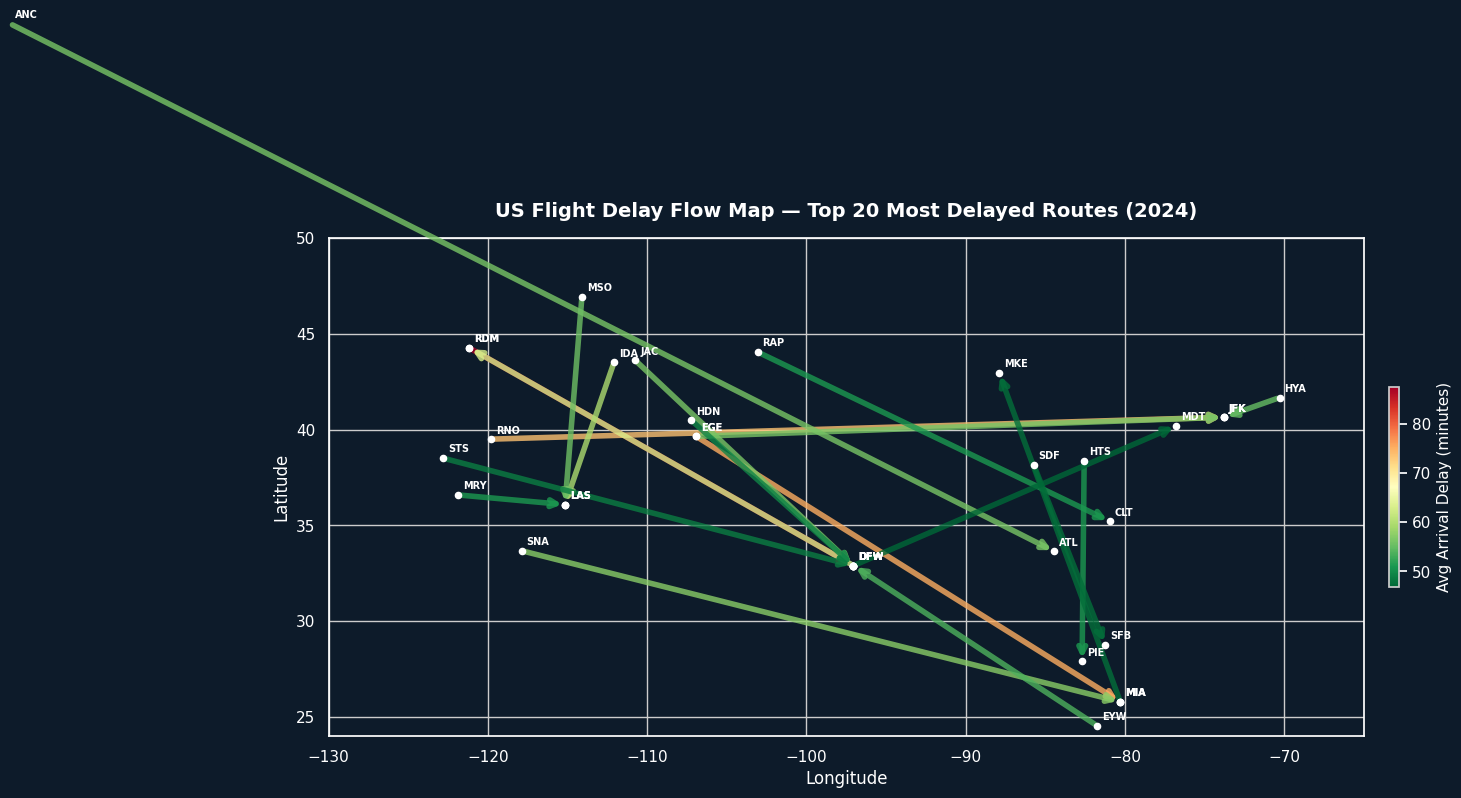

Static flow map saved as: flight_delay_flow_map_static.png


In [29]:
# =============================================================
# CN7031 - Flight Delay Flow Map (v2 - with regional airports)
# Shows delayed routes as arrows between airports
# Arrow thickness/colour = average delay severity
# =============================================================

from pyspark.sql import functions as F
import folium
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


# --- CELL 1: Get top delayed routes with airport coordinates ---

route_delay = df_clean.groupBy("origin", "dest").agg(
    F.count("*").alias("total_flights"),
    F.avg("arr_delay").alias("avg_arr_delay"),
    F.sum("is_delayed").alias("delayed_flights")
).withColumn(
    "delay_pct",
    (F.col("delayed_flights") / F.col("total_flights") * 100)
).filter(F.col("total_flights") >= 100) \
 .orderBy("avg_arr_delay", ascending=False) \
 .limit(20).toPandas()

print("Top 20 most delayed routes:")
print(route_delay[["origin", "dest", "total_flights", "avg_arr_delay", "delay_pct"]])


# --- CELL 2: Airport coordinates lookup (major + regional) ---

airport_coords = {
    # Major airports
    "ATL": (33.6407, -84.4277), "LAX": (33.9425, -118.4081),
    "ORD": (41.9742, -87.9073), "DFW": (32.8998, -97.0403),
    "DEN": (39.8561, -104.6737), "JFK": (40.6413, -73.7781),
    "SFO": (37.6213, -122.3790), "SEA": (47.4502, -122.3088),
    "LAS": (36.0840, -115.1537), "MCO": (28.4312, -81.3081),
    "EWR": (40.6895, -74.1745), "PHX": (33.4373, -112.0078),
    "IAH": (29.9902, -95.3368), "MIA": (25.7959, -80.2870),
    "BOS": (42.3656, -71.0096), "MSP": (44.8848, -93.2223),
    "DTW": (42.2162, -83.3554), "FLL": (26.0726, -80.1527),
    "CLT": (35.2140, -80.9431), "LGA": (40.7772, -73.8726),
    "BWI": (39.1754, -76.6682), "MDW": (41.7868, -87.7522),
    "SLC": (40.7899, -111.9791), "DCA": (38.8512, -77.0402),
    "SAN": (32.7338, -117.1933), "TPA": (27.9755, -82.5332),
    "PDX": (45.5898, -122.5951), "HOU": (29.6454, -95.2789),
    "STL": (38.7487, -90.3700), "BNA": (36.1245, -86.6782),
    "RDU": (35.8776, -78.7875), "MCI": (39.2976, -94.7139),
    "AUS": (30.1975, -97.6664), "OAK": (37.7213, -122.2208),
    "MEM": (35.0424, -89.9767), "CLE": (41.4117, -81.8498),
    "ONT": (34.0560, -117.6012), "RNO": (39.4991, -119.7681),
    "SRQ": (27.3953, -82.5544), "CAE": (33.9389, -81.1195),
    "PHL": (39.8721, -75.2411), "PIT": (40.4915, -80.2329),
    "IND": (39.7173, -86.2944), "CMH": (39.9980, -82.8919),
    "MKE": (42.9472, -87.8966), "OMA": (41.3032, -95.8941),
    "BUF": (42.9405, -78.7322), "JAX": (30.4941, -81.6879),
    "MSY": (29.9934, -90.2580), "SAT": (29.5337, -98.4698),
    # Regional airports
    "RDM": (44.2541, -121.1500),  # Redmond, OR
    "EGE": (39.6426, -106.9177),  # Eagle, CO
    "IDA": (43.5146, -112.0702),  # Idaho Falls, ID
    "SNA": (33.6757, -117.8682),  # Santa Ana, CA
    "JAC": (43.6073, -110.7377),  # Jackson Hole, WY
    "ANC": (61.1743, -149.9963),  # Anchorage, AK
    "MSO": (46.9163, -114.0906),  # Missoula, MT
    "HYA": (41.6693, -70.2803),   # Hyannis, MA
    "EYW": (24.5561, -81.7596),   # Key West, FL
    "RAP": (44.0453, -103.0574),  # Rapid City, SD
    "MRY": (36.5870, -121.8428),  # Monterey, CA
    "HTS": (38.3667, -82.5580),   # Huntington, WV
    "PIE": (27.9102, -82.6874),   # St. Petersburg, FL
    "HDN": (40.4812, -107.2218),  # Hayden, CO
    "STS": (38.5090, -122.8129),  # Santa Rosa, CA
    "SDF": (38.1744, -85.7360),   # Louisville, KY
    "SFB": (28.7776, -81.2375),   # Sanford, FL
    "MDT": (40.1935, -76.7634),   # Harrisburg, PA
}

# Add coordinates to route dataframe
route_delay["origin_lat"] = route_delay["origin"].map(lambda x: airport_coords.get(x, (None, None))[0])
route_delay["origin_lon"] = route_delay["origin"].map(lambda x: airport_coords.get(x, (None, None))[1])
route_delay["dest_lat"]   = route_delay["dest"].map(lambda x: airport_coords.get(x, (None, None))[0])
route_delay["dest_lon"]   = route_delay["dest"].map(lambda x: airport_coords.get(x, (None, None))[1])

# Keep only routes where both airports have coordinates
route_delay = route_delay.dropna(subset=["origin_lat", "origin_lon", "dest_lat", "dest_lon"])

print(f"\nRoutes with coordinates: {len(route_delay)}")
print(route_delay[["origin", "dest", "avg_arr_delay", "delay_pct"]])


# --- CELL 3: Build interactive Folium flow map ---

def delay_color(avg_delay, min_delay, max_delay):
    norm = (avg_delay - min_delay) / (max_delay - min_delay + 1e-9)
    norm = max(0, min(1, norm))
    if norm < 0.5:
        r = int(255 * norm * 2)
        g = 200
    else:
        r = 255
        g = int(200 * (1 - (norm - 0.5) * 2))
    return f"#{r:02x}{g:02x}00"

min_delay = route_delay["avg_arr_delay"].min()
max_delay = route_delay["avg_arr_delay"].max()

flight_map = folium.Map(location=[39.5, -98.35], zoom_start=4,
                         tiles="CartoDB positron")

for _, row in route_delay.iterrows():
    color = delay_color(row["avg_arr_delay"], min_delay, max_delay)
    weight = max(1, min(8, row["avg_arr_delay"] / 5))

    folium.PolyLine(
        locations=[[row["origin_lat"], row["origin_lon"]],
                   [row["dest_lat"],   row["dest_lon"]]],
        color=color,
        weight=weight,
        opacity=0.8,
        tooltip=f"{row['origin']} → {row['dest']} | Avg delay: {row['avg_arr_delay']:.1f} min | {row['delay_pct']:.1f}% delayed"
    ).add_to(flight_map)

    folium.RegularPolygonMarker(
        location=[row["dest_lat"], row["dest_lon"]],
        number_of_sides=3,
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.9
    ).add_to(flight_map)

airports_used = set(route_delay["origin"].tolist() + route_delay["dest"].tolist())
for code, (lat, lon) in airport_coords.items():
    if code in airports_used:
        folium.CircleMarker(
            location=[lat, lon],
            radius=5,
            color="navy",
            fill=True,
            fill_color="white",
            fill_opacity=1,
            tooltip=code
        ).add_to(flight_map)
        folium.Marker(
            location=[lat, lon],
            icon=folium.DivIcon(
                html=f'<div style="font-size:9px;font-weight:bold;color:navy">{code}</div>',
                icon_size=(30, 12),
                icon_anchor=(0, 0)
            )
        ).add_to(flight_map)

legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
            background-color: white; padding: 12px; border-radius: 8px;
            border: 1px solid #ccc; font-family: Arial; font-size: 13px;">
    <b>Avg Arrival Delay</b><br>
    <span style="color:#00c800">●</span> Low delay<br>
    <span style="color:#ff6400">●</span> Medium delay<br>
    <span style="color:#ff0000">●</span> High delay<br>
    <i style="font-size:11px">Line thickness = delay severity</i>
</div>
"""
flight_map.get_root().html.add_child(folium.Element(legend_html))

flight_map.save("flight_delay_flow_map.html")
print("Interactive flow map saved as: flight_delay_flow_map.html")


# --- CELL 4: Static flow map for report (matplotlib) ---

fig, ax = plt.subplots(figsize=(16, 9), facecolor="#0d1b2a")
ax.set_facecolor("#0d1b2a")
ax.set_xlim(-130, -65)
ax.set_ylim(24, 50)

norm = plt.Normalize(vmin=min_delay, vmax=max_delay)
cmap = plt.cm.RdYlGn_r

for _, row in route_delay.iterrows():
    color = cmap(norm(row["avg_arr_delay"]))
    lw = max(0.5, min(4, row["avg_arr_delay"] / 8))
    ax.annotate("",
        xy=(row["dest_lon"], row["dest_lat"]),
        xytext=(row["origin_lon"], row["origin_lat"]),
        arrowprops=dict(arrowstyle="->", color=color, lw=lw, alpha=0.8)
    )

for _, row in route_delay.iterrows():
    for lat, lon, code in [
        (row["origin_lat"], row["origin_lon"], row["origin"]),
        (row["dest_lat"], row["dest_lon"], row["dest"])
    ]:
        ax.scatter(lon, lat, color="white", s=20, zorder=5)
        ax.text(lon + 0.3, lat + 0.3, code, color="white",
                fontsize=7, zorder=6, fontweight="bold")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label("Avg Arrival Delay (minutes)", color="white", fontsize=11)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

ax.set_title("US Flight Delay Flow Map — Top 20 Most Delayed Routes (2024)",
             color="white", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Longitude", color="white")
ax.set_ylabel("Latitude", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("white")

plt.tight_layout()
plt.savefig("flight_delay_flow_map_static.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1b2a")
plt.show()
print("Static flow map saved as: flight_delay_flow_map_static.png")


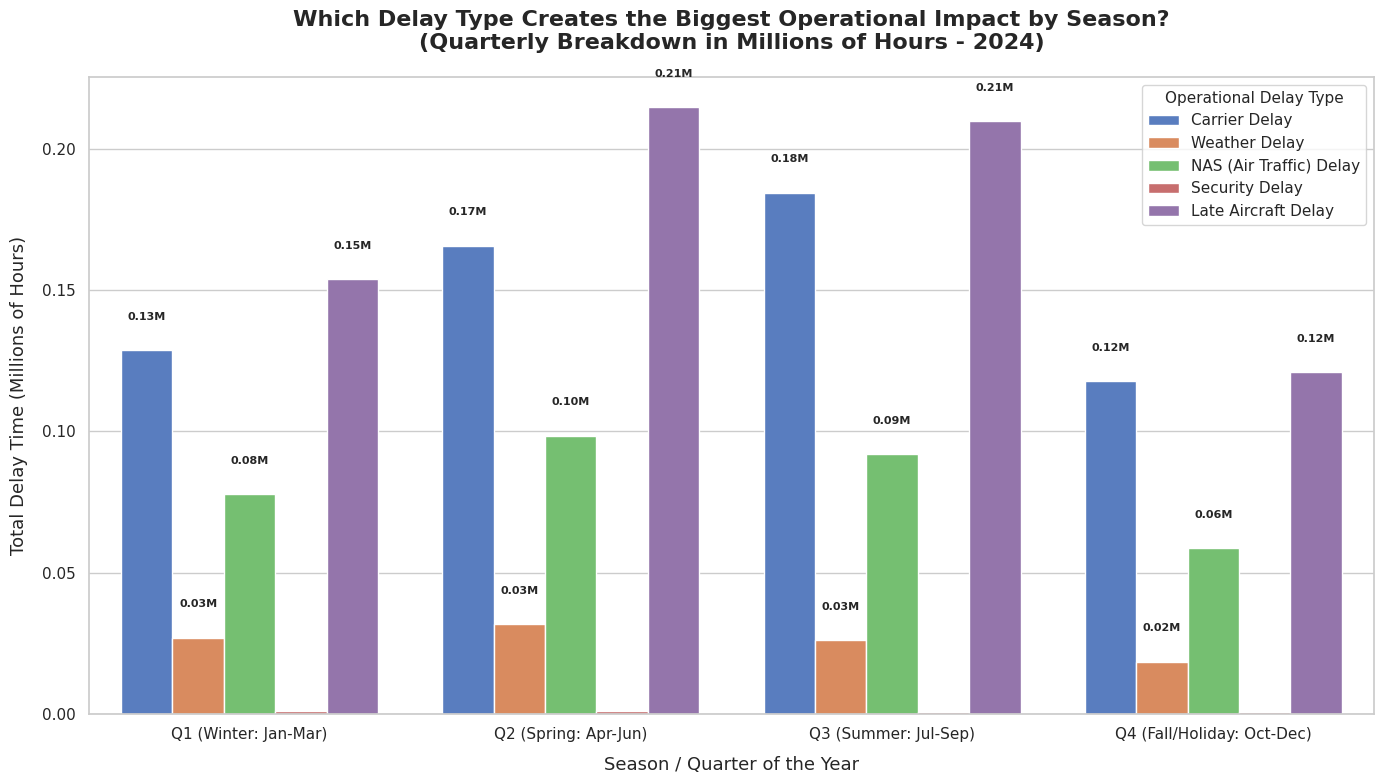

In [30]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. PURGE CANCELLED FLIGHTS & APPLY SEASONAL LOGIC (SPARK)
# ==============================================================================

# Filter out cancelled flights to analyze only successfully operated flights
df_operated = df.filter(F.col("cancelled") == 0)

# Create a Quarter/Season label column based on the integer month column
df_with_quarters = df_operated.withColumn(
    "season_quarter",
    F.when((F.col("month") >= 1) & (F.col("month") <= 3), "Q1 (Winter: Jan-Mar)")
     .when((F.col("month") >= 4) & (F.col("month") <= 6), "Q2 (Spring: Apr-Jun)")
     .when((F.col("month") >= 7) & (F.col("month") <= 9), "Q3 (Summer: Jul-Sep)")
     .otherwise("Q4 (Fall/Holiday: Oct-Dec)")
)

# Aggregate delay minutes by Quarter/Season (only for flights with actual delays)
seasonal_summary = df_with_quarters.filter(F.col("arr_delay") > 0).groupBy("season_quarter").agg(
    F.sum("carrier_delay").alias("Carrier Delay"),
    F.sum("weather_delay").alias("Weather Delay"),
    F.sum("nas_delay").alias("NAS (Air Traffic) Delay"),
    F.sum("security_delay").alias("Security Delay"),
    F.sum("late_aircraft_delay").alias("Late Aircraft Delay")
).orderBy("season_quarter").toPandas()


# ==============================================================================
# 2. DATA RESHAPING FOR GRAPHING (PANDAS)
# ==============================================================================

# Melt the wide DataFrame into a long format suitable for Seaborn plotting
seasonal_melted = seasonal_summary.melt(
    id_vars=["season_quarter"],
    var_name="Delay Type",
    value_name="Total Minutes"
)

# Convert total minutes into millions of hours for clean axis scaling
seasonal_melted["Total Hours (Millions)"] = seasonal_melted["Total Minutes"] / (60 * 1_000_000)


# ==============================================================================
# 3. VISUALIZATION GENERATION (SEABORN)
# ==============================================================================
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Create a grouped bar chart to compare delay types side-by-side per quarter
ax = sns.barplot(
    x="season_quarter",
    y="Total Hours (Millions)",
    hue="Delay Type",
    data=seasonal_melted,
    palette="muted"
)

# Aesthetics, titles, and axis labels
plt.title("Which Delay Type Creates the Biggest Operational Impact by Season?\n(Quarterly Breakdown in Millions of Hours - 2024)",
          fontsize=16, pad=20, weight='bold')
plt.xlabel("Season / Quarter of the Year", fontsize=13, labelpad=10)
plt.ylabel("Total Delay Time (Millions of Hours)", fontsize=13, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Place the legend cleanly inside or outside the chart
plt.legend(title="Operational Delay Type", title_fontsize='11', loc='upper right', frameon=True)

# Add numeric value labels on top of the bars for maximum readability
for p in ax.patches:
    height = p.get_height()
    if height > 0.01:  # Only display labels for visible bars to avoid clutter
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.01,
            f'{height:.2f}M',
            ha="center",
            va="bottom",
            fontsize=8,
            weight='semibold'
        )

plt.tight_layout()
plt.show()

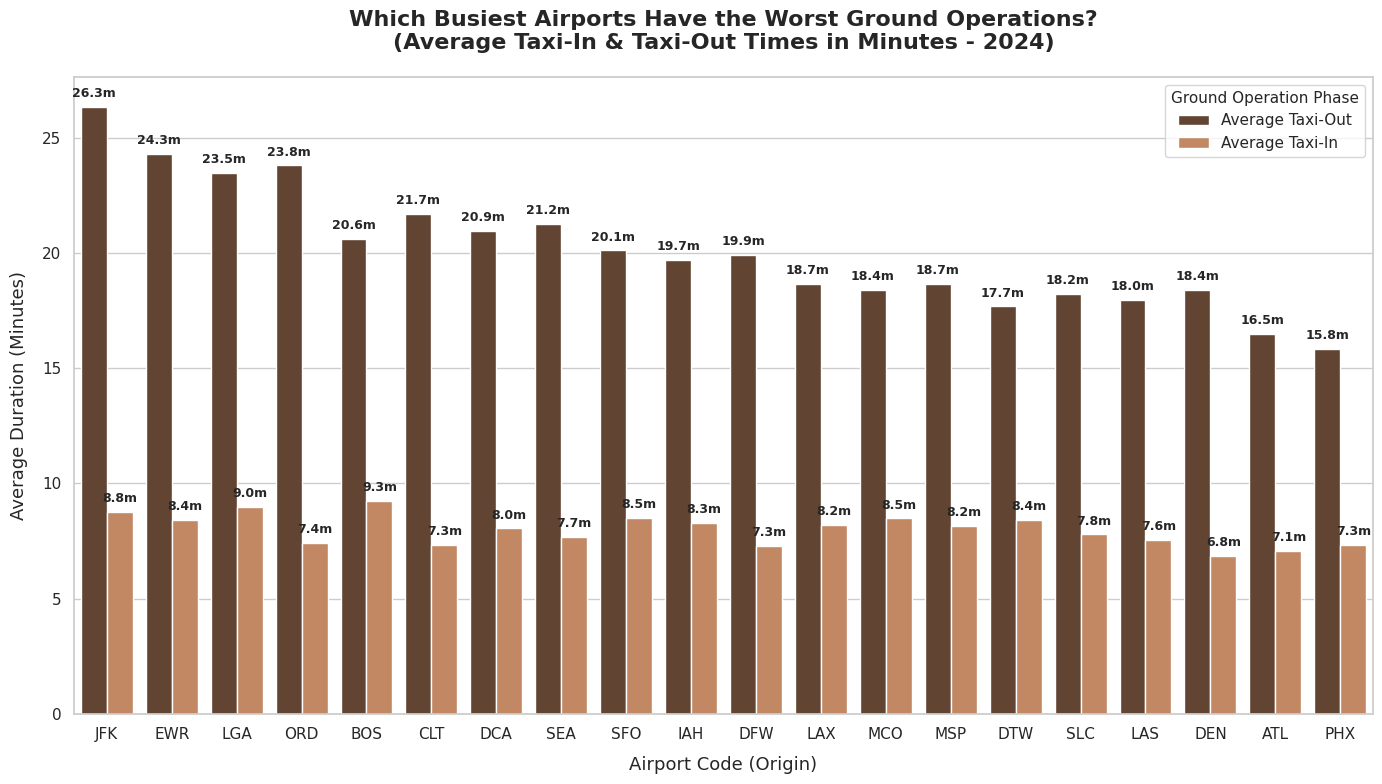

In [31]:
# Which Busiest Airports Have the Worst Ground Operations? (Average Taxi-In & Taxi-Out Times in Minutes - 2024)

from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. DATA FILTERING & AGGREGATION (SPARK)
# ==============================================================================

# Filter out cancelled flights since they don't perform full ground taxi operations
df_operated = df.filter(F.col("cancelled") == 0)

# Step A: Identify the Top 20 busiest airports by volume to avoid outlier small airports
top_airports = df_operated.groupBy("origin").count().orderBy(F.desc("count")).limit(20)
top_airport_list = [row["origin"] for row in top_airports.collect()]

# Step B: Filter main dataset for these Top 20 airports and calculate averages
ground_summary = df_operated.filter(F.col("origin").isin(top_airport_list)) \
    .groupBy("origin") \
    .agg(
        F.avg("taxi_out").alias("Average Taxi-Out"),
        F.avg("taxi_in").alias("Average Taxi-In")
    ) \
    .withColumn("Total Ground Time", F.col("Average Taxi-Out") + F.col("Average Taxi-In")) \
    .orderBy(F.desc("Total Ground Time")) \
    .toPandas()


# ==============================================================================
# 2. DATA RESHAPING FOR STACKED / GROUPED BAR CHART (PANDAS)
# ==============================================================================

# Melt the dataset to separate Taxi-In and Taxi-Out into rows for Seaborn
ground_melted = ground_summary.melt(
    id_vars=["origin", "Total Ground Time"],
    value_vars=["Average Taxi-Out", "Average Taxi-In"],
    var_name="Ground Operation Phase",
    value_name="Average Minutes"
)


# ==============================================================================
# 3. VISUALIZATION GENERATION (SEABORN)
# ==============================================================================
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Create a stacked or grouped bar chart. A grouped chart helps compare both phases clearly.
ax = sns.barplot(
    x="origin",
    y="Average Minutes",
    hue="Ground Operation Phase",
    data=ground_melted,
    palette="copper"
)

# Aesthetics, titles, and axis labels
plt.title("Which Busiest Airports Have the Worst Ground Operations?\n(Average Taxi-In & Taxi-Out Times in Minutes - 2024)",
          fontsize=16, pad=20, weight='bold')
plt.xlabel("Airport Code (Origin)", fontsize=13, labelpad=10)
plt.ylabel("Average Duration (Minutes)", fontsize=13, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Place the legend cleanly
plt.legend(title="Ground Operation Phase", title_fontsize='11', loc='upper right')

# Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.3,
            f'{height:.1f}m',
            ha="center",
            va="bottom",
            fontsize=9,
            weight='semibold'
        )

plt.tight_layout()
plt.show()

In [32]:
AIRPORT_COORDS = {
    "ABE":(40.6521,-75.4408,"Allentown"), "ABI":(32.4113,-99.6819,"Abilene"),
    "ABQ":(35.0402,-106.6092,"Albuquerque"), "ABR":(45.4491,-98.4218,"Aberdeen SD"),
    "ABY":(31.5355,-84.1945,"Albany GA"), "ALB":(42.7483,-73.8017,"Albany"),
    "AMA":(35.2194,-101.7059,"Amarillo"), "ANC":(61.1743,-149.9962,"Anchorage"),
    "ASE":(39.2232,-106.8688,"Aspen"), "ATL":(33.6407,-84.4277,"Atlanta"),
    "ATW":(44.2581,-88.5191,"Appleton"), "AUS":(30.1975,-97.6664,"Austin"),
    "AVL":(35.4362,-82.5418,"Asheville"), "AVP":(41.3385,-75.7234,"Scranton"),
    "BDL":(41.9389,-72.6832,"Hartford"), "BGR":(44.8074,-68.8281,"Bangor"),
    "BHM":(33.5629,-86.7535,"Birmingham"), "BIL":(45.8077,-108.5429,"Billings"),
    "BLI":(48.7927,-122.5375,"Bellingham"), "BLV":(38.5452,-89.8351,"Belleville IL"),
    "BMI":(40.4771,-88.9159,"Bloomington IL"), "BNA":(36.1245,-86.6782,"Nashville"),
    "BOI":(43.5644,-116.2228,"Boise"), "BOS":(42.3656,-71.0096,"Boston"),
    "BTM":(45.9548,-112.4975,"Butte"), "BTR":(30.5332,-91.1496,"Baton Rouge"),
    "BTV":(44.472,-73.1533,"Burlington VT"), "BUF":(42.9405,-78.7322,"Buffalo"),
    "BUR":(34.2007,-118.3585,"Burbank"), "BWI":(39.1774,-76.6684,"Baltimore"),
    "BZN":(45.7775,-111.153,"Bozeman"), "CAE":(33.9388,-81.1195,"Columbia SC"),
    "CAK":(40.9161,-81.4422,"Akron-Canton"), "CHA":(35.0353,-85.2038,"Chattanooga"),
    "CHS":(32.8986,-80.0405,"Charleston"), "CID":(41.8847,-91.7108,"Cedar Rapids"),
    "CLE":(41.4117,-81.8498,"Cleveland"), "CLT":(35.214,-80.9431,"Charlotte"),
    "CMH":(39.998,-82.8919,"Columbus"), "COS":(38.8058,-104.7008,"Colorado Springs"),
    "CRP":(27.7704,-97.5012,"Corpus Christi"), "CRW":(38.3731,-81.5932,"Charleston WV"),
    "CVG":(39.0489,-84.6678,"Cincinnati"), "DAB":(29.1799,-81.0581,"Daytona Beach"),
    "DAL":(32.8471,-96.8518,"Dallas Love"), "DAY":(39.9024,-84.2194,"Dayton"),
    "DCA":(38.8512,-77.0402,"Washington Reagan"), "DEN":(39.8561,-104.6737,"Denver"),
    "DFW":(32.8998,-97.0403,"Dallas-Fort Worth"), "DSM":(41.534,-93.6631,"Des Moines"),
    "DTW":(42.2162,-83.3554,"Detroit"), "ECP":(30.3417,-85.7973,"Panama City FL"),
    "EGE":(39.6426,-106.9177,"Vail/Eagle"), "ELM":(42.1599,-76.8916,"Elmira"),
    "ELP":(31.8072,-106.3781,"El Paso"), "ERI":(42.0831,-80.1739,"Erie"),
    "EUG":(44.1246,-123.212,"Eugene"), "EVV":(38.037,-87.5324,"Evansville"),
    "EWR":(40.6895,-74.1745,"Newark"), "EYW":(24.5561,-81.7596,"Key West"),
    "FAR":(46.9207,-96.8158,"Fargo"), "FAT":(36.7762,-119.7181,"Fresno"),
    "FCA":(48.3105,-114.256,"Kalispell"), "FLL":(26.0742,-80.1506,"Fort Lauderdale"),
    "FNT":(42.9655,-83.7436,"Flint"), "FSD":(43.582,-96.7419,"Sioux Falls"),
    "FWA":(40.9785,-85.1951,"Fort Wayne"), "GEG":(47.6199,-117.5339,"Spokane"),
    "GNV":(29.6901,-82.2718,"Gainesville"), "GPT":(30.4073,-89.0701,"Gulfport"),
    "GRB":(44.4851,-88.1296,"Green Bay"), "GRK":(31.0672,-97.8289,"Killeen"),
    "GRR":(42.8808,-85.5228,"Grand Rapids"), "GSO":(36.0978,-79.9373,"Greensboro"),
    "GSP":(34.8957,-82.2189,"Greenville"), "GTF":(47.482,-111.3707,"Great Falls"),
    "HDN":(40.4812,-107.2177,"Hayden CO"), "HLN":(46.6068,-111.9827,"Helena"),
    "HNL":(21.3187,-157.9225,"Honolulu"), "HOU":(29.6454,-95.2789,"Houston Hobby"),
    "HPN":(41.067,-73.7076,"Westchester"), "HRL":(26.2285,-97.6544,"Harlingen"),
    "HSV":(34.6372,-86.7751,"Huntsville"), "IAD":(38.9531,-77.4565,"Washington Dulles"),
    "IAH":(29.9902,-95.3368,"Houston Bush"), "ICT":(37.6499,-97.4331,"Wichita"),
    "IDA":(43.5146,-112.0708,"Idaho Falls"), "ILM":(34.2706,-77.9026,"Wilmington NC"),
    "IND":(39.7173,-86.2944,"Indianapolis"), "ISP":(40.7952,-73.1002,"Long Island"),
    "ITO":(19.7214,-155.0485,"Hilo"), "JAC":(43.6073,-110.7377,"Jackson Hole"),
    "JAN":(32.3112,-90.0759,"Jackson MS"), "JAX":(30.4941,-81.6879,"Jacksonville"),
    "JFK":(40.6413,-73.7781,"New York JFK"), "KOA":(19.7388,-156.0456,"Kona"),
    "LAS":(36.084,-115.1537,"Las Vegas"), "LAX":(33.9416,-118.4085,"Los Angeles"),
    "LBB":(33.6636,-101.8228,"Lubbock"), "LEX":(38.0365,-84.6059,"Lexington"),
    "LFT":(30.2053,-91.9876,"Lafayette"), "LGA":(40.7769,-73.874,"New York LaGuardia"),
    "LGB":(33.8177,-118.1516,"Long Beach"), "LIH":(21.976,-159.339,"Lihue"),
    "LIT":(34.7294,-92.2243,"Little Rock"), "MAF":(31.9425,-102.2019,"Midland"),
    "MCI":(39.2976,-94.7139,"Kansas City"), "MCO":(28.4312,-81.3081,"Orlando"),
    "MDW":(41.7868,-87.7522,"Chicago Midway"), "MEM":(35.0424,-89.9767,"Memphis"),
    "MFR":(42.3742,-122.8735,"Medford"), "MHT":(42.9326,-71.4357,"Manchester NH"),
    "MIA":(25.7959,-80.287,"Miami"), "MKE":(42.9472,-87.8966,"Milwaukee"),
    "MLB":(28.1028,-80.6453,"Melbourne"), "MLI":(41.4485,-90.5075,"Moline"),
    "MOB":(30.6912,-88.2428,"Mobile"), "MRY":(36.587,-121.8429,"Monterey"),
    "MSN":(43.1399,-89.3375,"Madison"), "MSO":(46.9163,-114.0906,"Missoula"),
    "MSP":(44.8848,-93.2223,"Minneapolis"), "MSY":(29.9934,-90.2581,"New Orleans"),
    "MTJ":(38.5098,-107.894,"Montrose"), "MYR":(33.6797,-78.9283,"Myrtle Beach"),
    "OAK":(37.7126,-122.2197,"Oakland"), "OGG":(20.8986,-156.4305,"Maui"),
    "OGS":(44.6819,-75.4655,"Ogdensburg"), "OKC":(35.3931,-97.6007,"Oklahoma City"),
    "OMA":(41.3032,-95.8941,"Omaha"), "ONT":(34.056,-117.6012,"Ontario CA"),
    "ORD":(41.9742,-87.9073,"Chicago O'Hare"), "ORF":(36.8946,-76.2012,"Norfolk"),
    "PBI":(26.6832,-80.0956,"West Palm Beach"), "PDX":(45.5887,-122.5975,"Portland OR"),
    "PGD":(26.9202,-81.9905,"Punta Gorda"), "PHL":(39.8744,-75.2424,"Philadelphia"),
    "PHX":(33.4342,-112.0116,"Phoenix"), "PIA":(40.6642,-89.6933,"Peoria"),
    "PIE":(27.9102,-82.6874,"St. Petersburg"), "PIT":(40.4915,-80.2329,"Pittsburgh"),
    "PNS":(30.4734,-87.1866,"Pensacola"), "PSC":(46.2647,-119.119,"Pasco WA"),
    "PSP":(33.8297,-116.5067,"Palm Springs"), "PVD":(41.724,-71.4282,"Providence"),
    "PVU":(40.2192,-111.7233,"Provo"), "PWM":(43.6462,-70.3093,"Portland ME"),
    "RAP":(44.0453,-103.0574,"Rapid City"), "RDM":(44.2541,-121.15,"Bend OR"),
    "RDU":(35.8801,-78.788,"Raleigh-Durham"), "RIC":(37.5052,-77.3197,"Richmond"),
    "RNO":(39.4991,-119.7681,"Reno"), "ROA":(37.3255,-79.9754,"Roanoke"),
    "ROC":(43.1189,-77.6724,"Rochester"), "RSW":(26.5362,-81.7552,"Fort Myers"),
    "SAN":(32.7338,-117.1933,"San Diego"), "SAT":(29.5337,-98.4698,"San Antonio"),
    "SAV":(32.1276,-81.2021,"Savannah"), "SBA":(34.4262,-119.8404,"Santa Barbara"),
    "SBN":(41.7087,-86.3173,"South Bend"), "SBP":(35.2368,-120.6424,"San Luis Obispo"),
    "SDF":(38.1744,-85.736,"Louisville"), "SEA":(47.4502,-122.3088,"Seattle"),
    "SFB":(28.7776,-81.2375,"Sanford"), "SFO":(37.6213,-122.379,"San Francisco"),
    "SGF":(37.2457,-93.3886,"Springfield MO"), "SHV":(32.4466,-93.8256,"Shreveport"),
    "SJC":(37.3639,-121.9289,"San Jose"), "SJU":(18.4394,-66.0018,"San Juan PR"),
    "SLC":(40.7899,-111.9791,"Salt Lake City"), "SMF":(38.6951,-121.5908,"Sacramento"),
    "SNA":(33.6757,-117.8682,"Orange County"), "SRQ":(27.3954,-82.5544,"Sarasota"),
    "STL":(38.7487,-90.37,"St. Louis"), "STS":(38.509,-122.8128,"Santa Rosa"),
    "STT":(18.3373,-64.9734,"St. Thomas"), "SYR":(43.1112,-76.1063,"Syracuse"),
    "TLH":(30.3965,-84.3503,"Tallahassee"), "TPA":(27.9755,-82.5332,"Tampa"),
    "TRI":(36.4752,-82.4074,"Tri-Cities TN"), "TUL":(36.1984,-95.8881,"Tulsa"),
    "TUS":(32.1161,-110.941,"Tucson"), "TYS":(35.811,-83.994,"Knoxville"),
    "VPS":(30.4832,-86.5254,"Destin-Ft Walton"), "XNA":(36.2819,-94.3068,"Fayetteville AR"),
    "YKM":(46.5682,-120.544,"Yakima"),
}

In [35]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import plotly.express as px
import pandas as pd

# 1. Initialize SPARK Session
spark = SparkSession.builder \
    .appName("CleanInteractiveFlightMap") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

# 2. Read Data
df_flights = spark.read.parquet(DATASET_PATH)

# 3. Build Airport Lookup from hardcoded AIRPORT_COORDS
airports_list = [
    {"iata_code": code, "name": name, "latitude_deg": lat, "longitude_deg": lon}
    for code, (lat, lon, name) in AIRPORT_COORDS.items()
]
df_airports = spark.createDataFrame(pd.DataFrame(airports_list))

df_airports_lookup = df_airports.filter(F.col("iata_code").isNotNull()) \
    .groupBy("iata_code") \
    .agg(
        F.first("name").alias("airport_name"),
        F.first("latitude_deg").alias("lat"),
        F.first("longitude_deg").alias("lon")
    )

# 4. Join Coordinates for Origin Airports
df_mapped = df_flights.join(
    df_airports_lookup,
    df_flights.origin == df_airports_lookup.iata_code,
    "inner"
)

# 5. Aggregate Total Flights per Airport per Month
df_monthly_airports = df_mapped.groupBy("month", "origin", "airport_name", "lat", "lon") \
    .count().withColumnRenamed("count", "total_flights")

# 6. Convert to Pandas DataFrame
pdf = df_monthly_airports.toPandas()

# Map month numbers to clean string labels for the UI
month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
             7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
pdf['month_name'] = pdf['month'].map(month_map)
pdf = pdf.sort_values("month")

# 7. Generate a Clean, Interactive Bubble Map
fig = px.scatter_geo(
    pdf,
    lat='lat',
    lon='lon',
    size='total_flights',
    color='total_flights',
    animation_frame='month_name',  # This fixes the slider tracking bug
    hover_name='airport_name',
    hover_data={'origin': True, 'total_flights': True, 'lat': False, 'lon': False, 'month_name': False},
    projection="albers usa",
    title="US Airport Flight Volumes by Month (2024)",
    color_continuous_scale=px.colors.sequential.Plasma,
    size_max=40
)

# 8. Clean up UI elements and map style
fig.update_layout(
    geo=dict(
        scope='usa',
        landcolor='rgb(240, 240, 240)',
        countrycolor='rgb(204, 204, 204)',
        showlakes=True,
        lakecolor='rgb(255, 255, 255)'
    ),
    margin={"r":0,"t":50,"l":0,"b":0}
)

# Force display inside Jupyter desktop layout safely
fig.show(renderer="iframe")

In [34]:
from pyspark.sql import functions as F
import pandas as pd
import plotly.express as px

month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

# --- CELL 1: Prepare data ---
airline_monthly = df_clean.groupBy("month", "op_unique_carrier").agg(
    F.count("*").alias("total_flights"),
    F.avg("arr_delay").alias("avg_arr_delay"),
    F.sum("is_delayed").alias("delayed_flights")
).withColumn(
    "delay_pct",
    (F.col("delayed_flights") / F.col("total_flights") * 100)
).filter(F.col("total_flights") >= 50).toPandas()

airline_monthly["month_name"] = airline_monthly["month"].map(month_map)
airline_monthly = airline_monthly.sort_values(
    ["month", "avg_arr_delay"], ascending=[True, False]
)

# --- CELL 2: Racing bar chart ---
fig_race = px.bar(
    airline_monthly,
    x="avg_arr_delay",
    y="op_unique_carrier",
    color="avg_arr_delay",
    animation_frame="month_name",
    orientation="h",
    title="Airline Delay Rankings by Month — 2024<br><sup>Which airline had the worst delays each month?</sup>",
    labels={
        "avg_arr_delay": "Avg Arrival Delay (minutes)",
        "op_unique_carrier": "Airline",
        "month_name": "Month"
    },
    color_continuous_scale="RdYlGn_r",
    range_x=[0, airline_monthly["avg_arr_delay"].max() * 1.1],
    hover_data={"delay_pct": ":.1f", "total_flights": True}
)

fig_race.update_layout(
    paper_bgcolor="#0d1b2a",
    plot_bgcolor="#1a1a2e",
    font=dict(color="white", size=12),
    coloraxis_showscale=False,
    height=550,
    xaxis=dict(gridcolor="#333355"),
    yaxis=dict(gridcolor="#333355", categoryorder="total ascending"),
    updatemenus=[dict(
        type="buttons",
        showactive=False,
        y=-0.15,
        x=0.5,
        xanchor="center",
        buttons=[
            dict(label="▶ Play",
                 method="animate",
                 args=[None, dict(frame=dict(duration=800, redraw=True),
                                  fromcurrent=True)]),
            dict(label="⏸ Pause",
                 method="animate",
                 args=[[None], dict(frame=dict(duration=0, redraw=False),
                                     mode="immediate")])
        ]
    )]
)

fig_race.show()
fig_race.write_html("plotly_airline_race.html")
print("Saved: plotly_airline_race.html")

Saved: plotly_airline_race.html
